In [1]:
# !pip install Pillow Attention matplotlib

In [2]:
# !pip install scipy

In [3]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import pathlib
import matplotlib.pyplot as plt
import shutil
import distutils.dir_util
import matplotlib.image as mpimg
import scipy


# TF_ENABLE_ONEDNN_OPTS=0

2025-07-24 03:39:41.001529: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-24 03:39:41.092493: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-24 03:39:41.092541: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-24 03:39:41.093757: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-24 03:39:41.113126: I tensorflow/core/platform/cpu_feature_guar

In [4]:
import tensorflow as tf
print(tf.__version__)

2.15.0


In [5]:
import tensorflow as tf
print(tf.test.is_gpu_available())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True


2025-07-24 03:39:44.684399: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 856 MB memory:  -> device: 0, name: NVIDIA L40, pci bus id: 0000:c9:00.0, compute capability: 8.9


In [6]:
image_generator_train = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1)

In [7]:
image_generator_test = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

In [8]:
#################################################################################################################
##beocat - '/homes/adalal/transfer_data10Classes/training'
##local - 'C:/Users/adalal/OneDrive - Kansas State University/PhD/Research/Dataset/transfer_data10Classes/training'
#################################################################################################################

train_dataset = image_generator_train.flow_from_directory(batch_size=32,
                                                 directory= 'sun_dataset-10class/train',
                                                 shuffle=True,
                                                 target_size=(299, 299), 
                                                 subset="training",
                                                 class_mode='categorical')

validation_dataset = image_generator_train.flow_from_directory(batch_size=32,
                                                 directory= 'sun_dataset-10class/train',
                                                 shuffle=False,
                                                 target_size=(299, 299), 
                                                 subset="validation",
                                                 class_mode='categorical')



Found 2846 images belonging to 10 classes.
Found 311 images belonging to 10 classes.


In [9]:
###########################################################
##beocat - '/homes/adalal/transfer_data10Classes/validation'
###########################################################
test_dataset = image_generator_test.flow_from_directory(batch_size=32,
                                                 directory='sun_dataset-10class/test',
                                                 shuffle=False,
                                                 target_size=(299, 299), 
                                                 class_mode='categorical')


Found 793 images belonging to 10 classes.


In [10]:
train_dataset.num_classes

10

In [11]:
from tensorflow.keras.applications import ResNet50V2, VGG16, InceptionV3
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import AveragePooling2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [12]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [13]:

# load the ResNet-50 network, ensuring the head FC layer sets are left # off

print("[INFO] preparing model...")
baseModel = InceptionV3(weights="imagenet", include_top=False,
	input_tensor=Input(shape=(299, 299, 3)))

#summary of the resnet50 model
#baseModel.summary()
for layer in baseModel.layers[:]:
    layer.trainable = False
# for layer in baseModel.layers[-2:]:
#     layer.trainable = True
# for layer in baseModel.layers[-12:]:
#     if isinstance(layer, tf.keras.layers.Conv2D):
#         layer.trainable = True
#     # Also unfreeze the corresponding batch normalization and activation layers if needed
#     elif isinstance(layer, (tf.keras.layers.BatchNormalization, tf.keras.layers.Activation)):
#         layer.trainable = True


[INFO] preparing model...


2025-07-24 03:39:45.039189: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 856 MB memory:  -> device: 0, name: NVIDIA L40, pci bus id: 0000:c9:00.0, compute capability: 8.9


In [14]:
for layer in baseModel.layers[-15:]:
    print(layer)

In [15]:
len(baseModel.layers)

311

In [16]:
# construct the head of the model that will be placed on top of the
# the base model
headModel = baseModel.output
headModel = BatchNormalization()(headModel)
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
# headModel = BatchNormalization()(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
# headModel = BatchNormalization()(headModel)
headModel = Dropout(0.5)(headModel)


headModel = Dense(train_dataset.num_classes, activation="softmax")(headModel)

# place the head FC model on top of the base model (this will become
# the actual model we will train)
model = Model(inputs=baseModel.input, outputs=headModel)

# loop over all layers in the base model and freeze them so they will
# *not* be updated during the training process


#summary of the resnet50 model    
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 149, 149, 32)         864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 149, 149, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 149, 149, 32)         0         ['batch_normalization[0][0

In [17]:
# compile the model

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#adam = Adam(learning_rate=1e-4, decay=1e-4/20)
adam = Adam(learning_rate=0.001)
model.compile(optimizer= adam,loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
# train the model
print("[INFO] training model...")

H = model.fit(
    train_dataset,
    steps_per_epoch = train_dataset.samples // 32,
    validation_data = validation_dataset, 
    validation_steps = validation_dataset.samples  // 32,
    epochs = 30,
    verbose=1,
    callbacks=[early_stopping]
)

[INFO] training model...
Epoch 1/30


2025-07-24 03:39:57.004002: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-07-24 03:39:57.786957: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 269.30MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-07-24 03:39:57.789373: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 269.30MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-07-24 03:39:57.789394: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 269.30MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there co

88/88 [==============================] - 137s 1s/step - loss: 0.6667 - accuracy: 0.7935 - val_loss: 0.3470 - val_accuracy: 0.8958
Epoch 2/30
88/88 [==============================] - 93s 1s/step - loss: 0.3362 - accuracy: 0.8952 - val_loss: 0.2774 - val_accuracy: 0.8958
Epoch 3/30
88/88 [==============================] - 82s 938ms/step - loss: 0.2943 - accuracy: 0.9090 - val_loss: 0.2413 - val_accuracy: 0.9201
Epoch 4/30
88/88 [==============================] - 80s 905ms/step - loss: 0.2511 - accuracy: 0.9176 - val_loss: 0.2375 - val_accuracy: 0.9236
Epoch 5/30
88/88 [==============================] - 78s 890ms/step - loss: 0.2117 - accuracy: 0.9296 - val_loss: 0.2530 - val_accuracy: 0.8958
Epoch 6/30
88/88 [==============================] - 80s 906ms/step - loss: 0.2008 - accuracy: 0.9307 - val_loss: 0.2438 - val_accuracy: 0.9271
Epoch 7/30
88/88 [==============================] - 79s 894ms/step - loss: 0.2114 - accuracy: 0.9275 - val_loss: 0.2356 - val_accuracy: 0.9132
Epoch 8/30
88/8

In [21]:
# Get predictions
predictions = model.predict(test_dataset, verbose=1)

# Convert predictions to class labels
y_pred = np.argmax(predictions, axis=1)  # Predicted class indices
y_true = test_dataset.classes  # True class indices from generator
class_labels = list(test_dataset.class_indices.keys())  # Class names

25/25 [==============================] - 71s 3s/step


Test Accuracy: 0.9395


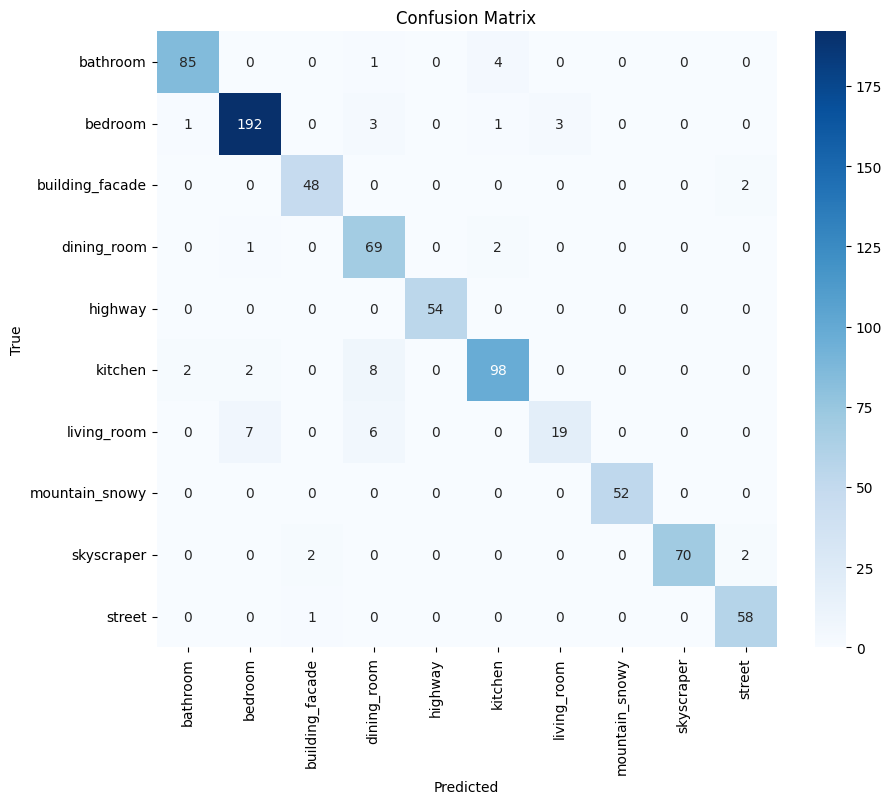

In [22]:
!pip install scikit-learn seaborn
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [23]:
# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# Print classification report in a formatted way
print("Classification Report:")
print(f"{'Class':<20} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
print("-" * 60)
for class_name, metrics in report.items():
    if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
        print(f"{class_name:<20} {metrics['precision']:<10.4f} {metrics['recall']:<10.4f} {metrics['f1-score']:<10.4f} {metrics['support']:<10}")
print("-" * 60)
print(f"{'Macro Avg':<20} {report['macro avg']['precision']:<10.4f} {report['macro avg']['recall']:<10.4f} {report['macro avg']['f1-score']:<10.4f} {report['macro avg']['support']:<10}")
print(f"{'Weighted Avg':<20} {report['weighted avg']['precision']:<10.4f} {report['weighted avg']['recall']:<10.4f} {report['weighted avg']['f1-score']:<10.4f} {report['weighted avg']['support']:<10}")
print(f"Overall Accuracy: {report['accuracy']:.4f}")

Classification Report:
Class                Precision  Recall     F1-Score   Support   
------------------------------------------------------------
bathroom             0.9659     0.9444     0.9551     90.0      
bedroom              0.9505     0.9600     0.9552     200.0     
building_facade      0.9412     0.9600     0.9505     50.0      
dining_room          0.7931     0.9583     0.8679     72.0      
highway              1.0000     1.0000     1.0000     54.0      
kitchen              0.9333     0.8909     0.9116     110.0     
living_room          0.8636     0.5938     0.7037     32.0      
mountain_snowy       1.0000     1.0000     1.0000     52.0      
skyscraper           1.0000     0.9459     0.9722     74.0      
street               0.9355     0.9831     0.9587     59.0      
------------------------------------------------------------
Macro Avg            0.9383     0.9236     0.9275     793.0     
Weighted Avg         0.9416     0.9395     0.9386     793.0     
Overall Ac

In [ ]:
import tensorflow as tf

# Clear the current session
tf.keras.backend.clear_session()

In [25]:
steps_per_epoch=(train_dataset.samples/32)
steps_per_epoch

171.875

In [24]:
# save it as a h5 file
model.save('model_INCEPTIONV3_sun10_jul23.h5')

/usr/local/lib/python3.9/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [26]:
from tensorflow.keras.models import load_model
model = load_model('model_INCEPTIONV3_sun10_jul23.h5')
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 149, 149, 32)         864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 149, 149, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 149, 149, 32)         0         ['batch_normalization[0][0

In [ ]:
############################################################################################################

In [ ]:
############################################################################################################################

In [ ]:
#############################################################################################
###################GETTING DESIRED LAYER FROM MODEL#########################################
#############################################################################################

In [29]:
##################to get the output of n layers or whole model#######################
layer_outputs = [layer.output for layer in model.layers[-3:-2]]
#layer_outputs = [layer.output for layer in model.layers[-3:-2]]
layer_outputs

[<KerasTensor: shape=(None, 64) dtype=float32 (created by layer 'dense')>]

In [30]:
layer_names = [layer.name for layer in model.layers[-3:-2]]
layer_names

['dense']

In [31]:
from tensorflow.keras.models import Model
feature_map_model = Model(inputs=model.input, outputs=layer_outputs)


In [32]:
feature_map_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 149, 149, 32)         864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 149, 149, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 149, 149, 32)         0         ['batch_normalization[0]

In [7]:
#############################################################################################
###################TO GET PREDICTIONS ON WHOLE MODEL#########################################
#############################################################################################

In [33]:
#prediction for test datasets
predIdxs = model.predict_generator(test_dataset, steps=(test_dataset.samples // 32) + 1)

/tmp/ipykernel_1195464/2727755112.py:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predIdxs = model.predict_generator(test_dataset, steps=(test_dataset.samples // 32) + 1)


In [34]:
predIdxs.shape


(793, 10)

In [35]:
predIdxs

array([[9.99999762e-01, 4.18013322e-08, 2.83097124e-09, ...,
        1.52252481e-11, 2.02655315e-08, 1.11488185e-09],
       [7.58452434e-03, 8.92488137e-02, 8.83116736e-04, ...,
        2.71554483e-04, 2.34838546e-04, 1.12023891e-03],
       [9.99984980e-01, 9.25599295e-08, 7.02653136e-09, ...,
        6.54286403e-10, 1.31152561e-07, 4.31859526e-09],
       ...,
       [5.59762126e-10, 1.13182880e-10, 1.74956192e-08, ...,
        4.63720867e-11, 2.81890362e-11, 9.99999523e-01],
       [6.67566482e-08, 1.09616444e-07, 1.03377670e-05, ...,
        1.98677611e-07, 5.81554048e-07, 9.99978185e-01],
       [4.72764668e-07, 1.00252703e-06, 8.09080884e-05, ...,
        4.58583642e-08, 2.92303980e-07, 9.99889970e-01]], dtype=float32)

In [36]:
# Get classes by max element in np (as a list)
classes = list(np.argmax(predIdxs, axis=1))
# Get filenames (set shuffle=false in generator is important)
filenames = test_dataset.filenames

In [37]:
import pandas as pd
df=pd.DataFrame(predIdxs)
df['filenames'] = filenames
print(df)

                0             1             2             3             4  \
0    9.999998e-01  4.180133e-08  2.830971e-09  1.090851e-07  3.670730e-10   
1    7.584524e-03  8.924881e-02  8.831167e-04  7.062048e-01  7.083538e-05   
2    9.999850e-01  9.255993e-08  7.026531e-09  1.059272e-05  7.855878e-08   
3    1.000000e+00  7.170262e-11  7.928846e-14  3.515458e-11  1.120640e-13   
4    9.999990e-01  5.612592e-08  1.610035e-09  1.174665e-08  6.847859e-11   
..            ...           ...           ...           ...           ...   
788  5.137520e-08  6.705039e-08  1.037498e-04  1.466454e-08  1.387879e-04   
789  9.101998e-07  5.130383e-07  6.683265e-03  5.686035e-07  3.499625e-05   
790  5.597621e-10  1.131829e-10  1.749562e-08  1.848413e-12  4.063947e-07   
791  6.675665e-08  1.096164e-07  1.033777e-05  5.903711e-10  1.039724e-05   
792  4.727647e-07  1.002527e-06  8.090809e-05  1.002055e-08  2.538499e-05   

                5             6             7             8             9  

In [38]:
df.to_csv (r'predictions_of_tenNeurons_sun10_july23.csv', index = None, header=True) 

In [39]:
label_map = (test_dataset.class_indices)

In [40]:
label_map

{'bathroom': 0,
 'bedroom': 1,
 'building_facade': 2,
 'dining_room': 3,
 'highway': 4,
 'kitchen': 5,
 'living_room': 6,
 'mountain_snowy': 7,
 'skyscraper': 8,
 'street': 9}

In [73]:
import pandas as pd
b = [(x[0], y) for x in  zip(classes, filenames) for y in x[1:]]
df = pd.DataFrame(b, columns=['Predicted_classes','image_name'])
print (df)
df.to_csv (r'finalClass_with_image_name_sun10_july23.csv', index = None, header=True) 

     Predicted_classes                              image_name
0                    0  bathroom/test_sun_aacopdmawrifxaso.jpg
1                    3  bathroom/test_sun_aaoplqapkfcogulx.jpg
2                    0  bathroom/test_sun_aapitsgbtktqubfy.jpg
3                    0  bathroom/test_sun_aaurzltrbxfksuhz.jpg
4                    0  bathroom/test_sun_aavhrsfjbserjtht.jpg
..                 ...                                     ...
788                  9   street/train_sun_aoyqphhfhhsnqjcm.jpg
789                  9   street/train_sun_apwlhjpslzmvagnl.jpg
790                  9   street/train_sun_apyfnhyfvypuwjsx.jpg
791                  9   street/train_sun_atzyjadgkypylonu.jpg
792                  9   street/train_sun_avvftortkvixvqjx.jpg

[793 rows x 2 columns]


In [42]:
pred_labels = np.argmax(predIdxs, axis=1)

In [43]:
from sklearn.metrics import classification_report
print("[INFO] evaluating network...")
print(classification_report(test_dataset.classes, pred_labels,
	target_names=test_dataset.class_indices.keys()))

[INFO] evaluating network...
                 precision    recall  f1-score   support

       bathroom       0.97      0.94      0.96        90
        bedroom       0.95      0.96      0.96       200
building_facade       0.94      0.96      0.95        50
    dining_room       0.79      0.96      0.87        72
        highway       1.00      1.00      1.00        54
        kitchen       0.93      0.89      0.91       110
    living_room       0.86      0.59      0.70        32
 mountain_snowy       1.00      1.00      1.00        52
     skyscraper       1.00      0.95      0.97        74
         street       0.94      0.98      0.96        59

       accuracy                           0.94       793
      macro avg       0.94      0.92      0.93       793
   weighted avg       0.94      0.94      0.94       793



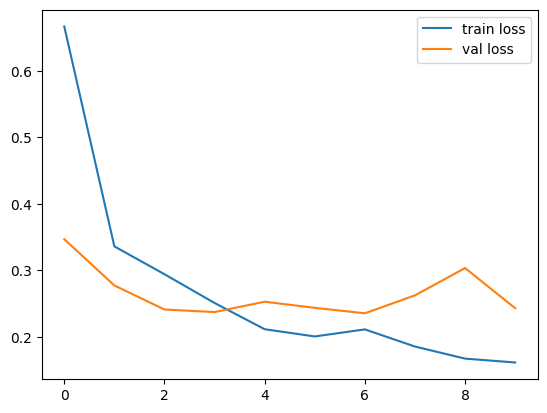

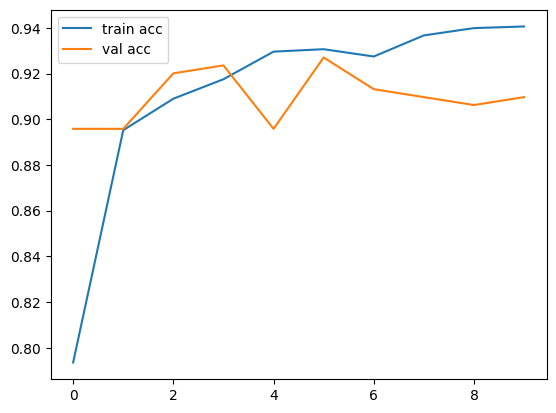

<Figure size 640x480 with 0 Axes>

In [44]:
# plot the loss
plt.plot(H.history['loss'], label='train loss')
plt.plot(H.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_resnet50V2_unfreeze')

# plot the accuracy
plt.plot(H.history['accuracy'], label='train acc')
plt.plot(H.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_resnet50V2_unfreeze')

In [ ]:
#############################################################################################
###################ACTIVATIONS OF LAST DENSE LAYER###########################################
#############################################################################################

In [45]:
#prediction for test datasets
predIdxs = feature_map_model.predict_generator(test_dataset, steps=(test_dataset.samples // 32) + 1)

/tmp/ipykernel_1195464/3627181323.py:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predIdxs = feature_map_model.predict_generator(test_dataset, steps=(test_dataset.samples // 32) + 1)


In [47]:
import pandas as pd
df=pd.DataFrame(predIdxs)
df['filenames'] = filenames
print(df)
df.to_csv (r'preds_of_64Neurons_denseLayer_793_sun10_july23.csv', index = None, header=True) 

       0         1         2    3         4         5         6         7  \
0    0.0  0.000000  0.000000  0.0  4.499814  0.000000  5.143057  0.000000   
1    0.0  0.000000  0.000000  0.0  0.635124  0.000000  0.000000  0.714403   
2    0.0  0.000000  0.000000  0.0  1.120438  0.000000  4.530458  0.086476   
3    0.0  0.000000  0.000000  0.0  5.039873  0.000000  7.004512  0.000000   
4    0.0  0.466744  0.000000  0.0  3.844545  1.592968  3.289480  0.000000   
..   ...       ...       ...  ...       ...       ...       ...       ...   
788  0.0  2.645312  3.611036  0.0  0.000000  1.903007  8.380760  0.000000   
789  0.0  0.808971  3.622514  0.0  0.000000  1.667008  6.421746  0.000000   
790  0.0  1.120922  5.091410  0.0  0.000000  4.695629  8.163487  0.000000   
791  0.0  0.953350  4.114945  0.0  0.000000  3.203368  8.041868  0.000000   
792  0.0  0.171971  2.495070  0.0  0.784076  2.534279  8.175721  0.000000   

            8         9  ...   55        56        57        58        59  

In [ ]:
###########################Prediction for Single Image################

In [78]:
label_map

{'bathroom': 0,
 'bedroom': 1,
 'building_facade': 2,
 'dining_room': 3,
 'highway': 4,
 'kitchen': 5,
 'living_room': 6,
 'mountain_snowy': 7,
 'skyscraper': 8,
 'street': 9}

In [88]:
from   tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.preprocessing import image
img_path='sun_dataset-10class/images/train/living_room/test_sun_acsnqopieawmfmdp.jpg' 


img = load_img(img_path, target_size=(299, 299))  # this is a PIL image
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
# x /= 255.0
x = tf.keras.applications.inception_v3.preprocess_input(x)

preds = model.predict(x)
# Interpret the prediction
class_index = np.argmax(preds)  
class_prob = preds[0, class_index]
print(class_index)
print(preds)
print(class_prob)

1/1 [==============================] - 0s 26ms/step
6
[[1.7510143e-06 1.2115136e-03 9.3132921e-06 2.5205722e-05 9.9395413e-07
  9.2151316e-07 9.9874806e-01 1.3315222e-06 8.3111800e-08 8.8111284e-07]]
0.99874806


In [ ]:
###########################Prediction for Batch Images################

In [ ]:
###########################CODE 3#####################################

In [7]:
from tensorflow.keras.preprocessing import image
import numpy as np
import pandas as pd

# List of new classes to test
new_classes = ['skyscraper','street']
               #'highway','kitchen','living_room','skyscraper','street']
#new_classes = ['edifice and skyscraper']

# Directory containing the test images for the new classes
test_directory = '/homes/adalal/transfer_data10Classes/training'
#test_directory = '/homes/adalal/new_research_dataset_jun2023/google_dataset_top1_eciiConcept/neuron_63_and'

# Create an ImageDataGenerator for rescaling
rescale_generator = image.ImageDataGenerator(rescale=1./255)

# Load the test images for the new classes
test_images = []
filenames = []
class_names = []
for class_name in new_classes:
    class_directory = os.path.join(test_directory, class_name)
    for image_name in os.listdir(class_directory):
        image_path = os.path.join(class_directory, image_name)
        try:
            img = image.load_img(image_path, target_size=(224, 224))
            img = image.img_to_array(img)
            img = np.expand_dims(img, axis=0)
            img = rescale_generator.standardize(img)
            test_images.append(img)
            filenames.append(image_name)
            class_names.append(class_name)
        except:
            print("Corrupt image:", image_name)

# Concatenate the test images into a single array
test_images = np.concatenate(test_images)

# Perform predictions for the new test images
predIdxs = model.predict(test_images)


# Get classes by max element in predIdxs (as a list)
classes = list(np.argmax(predIdxs, axis=1))

# Get filenames
#filenames = test_dataset.filenames

# Create a dataframe with predIdxs, filenames, and classes
df=pd.DataFrame(predIdxs)
df['Class_names'] = class_names
df['filenames'] = filenames
df['Predicted_classes'] = classes


print(df)
df.to_csv (r'ADE20K_traindataset3_predictions.csv', index = None, header=True) 

                 0             1         2             3             4  \
0     1.436114e-08  4.284212e-08  0.000839  6.209355e-08  1.066952e-07   
1     2.896217e-10  1.217452e-08  0.000091  6.152798e-10  4.391332e-08   
2     1.699557e-07  7.701169e-07  0.000851  1.192189e-07  8.216002e-07   
3     4.547031e-05  1.850309e-04  0.004967  2.460377e-05  8.205022e-05   
4     1.135112e-08  1.937607e-07  0.001017  3.542957e-08  2.780592e-07   
...            ...           ...       ...           ...           ...   
2353  2.302848e-10  1.048194e-09  0.000088  3.745731e-11  7.239598e-10   
2354  6.426962e-07  1.690867e-06  0.066920  9.153984e-07  9.503091e-07   
2355  1.659533e-07  2.454895e-07  0.056568  8.545585e-08  2.136527e-08   
2356  1.271261e-09  1.248235e-08  0.000409  2.308606e-08  7.545552e-08   
2357  1.530590e-09  2.547155e-08  0.001472  2.859726e-09  1.170209e-08   

                 5             6             7             8         9  \
0     6.501495e-06  4.093183e-08  3.4

In [25]:
predIdxs

array([[2.03886293e-06, 3.79114931e-06, 1.01986386e-01, ...,
        3.23193308e-06, 1.19855140e-04, 8.97883058e-01],
       [3.33790195e-09, 1.21119923e-08, 2.03699383e-04, ...,
        6.37851585e-08, 8.63037570e-08, 9.99795854e-01],
       [9.25770749e-09, 5.12016882e-08, 1.01979694e-03, ...,
        4.35672654e-08, 3.40163024e-06, 9.98935759e-01],
       ...,
       [2.15408472e-05, 1.11227146e-05, 9.87024903e-01, ...,
        1.51881231e-05, 6.05218171e-04, 1.21009247e-02],
       [1.19637280e-05, 6.86286103e-06, 2.95873672e-01, ...,
        5.31881269e-05, 4.34791655e-05, 7.04000950e-01],
       [2.04522098e-06, 6.08520986e-06, 3.35750222e-01, ...,
        8.47259798e-06, 2.96346261e-04, 6.63752556e-01]], dtype=float32)

In [ ]:
######################################CODE 3 WITH DENSE LAYER#####################

In [7]:
from tensorflow.keras.preprocessing import image
import numpy as np
import pandas as pd

# List of new classes to test
new_classes = ['skyscraper','street']
               #,'skyscraper','street']
#new_classes = ['edifice and skyscraper']

# Directory containing the test images for the new classes
test_directory = '/homes/adalal/transfer_data10Classes/training'
#test_directory = '/homes/adalal/new_research_dataset_jun2023/google_dataset_2nd_eciiConcept/neuron_58'


# Create an ImageDataGenerator for rescaling
rescale_generator = image.ImageDataGenerator(rescale=1./255)

# Load the test images for the new classes
test_images = []
filenames = []
class_names = []
for class_name in new_classes:
    class_directory = os.path.join(test_directory, class_name)
    for image_name in os.listdir(class_directory):
        image_path = os.path.join(class_directory, image_name)
        img = image.load_img(image_path, target_size=(224, 224))
        img = image.img_to_array(img)
        img = np.expand_dims(img, axis=0)
        img = rescale_generator.standardize(img)
        test_images.append(img)
        filenames.append(image_name)
        class_names.append(class_name)

# Concatenate the test images into a single array
test_images = np.concatenate(test_images)

# Perform predictions for the new test images
predIdxs = feature_map_model.predict(test_images)


# Get classes by max element in predIdxs (as a list)
classes = list(np.argmax(predIdxs, axis=1))

# Get filenames
#filenames = test_dataset.filenames

# Create a dataframe with predIdxs, filenames, and classes
df=pd.DataFrame(predIdxs)
df['Class_names'] = class_names
df['filenames'] = filenames
#df['Predicted_classes'] = classes


print(df)
df.to_csv (r'ADE20K_traindataset3_denseactivations.csv', index = None, header=True) 

             0         1    2         3    4    5         6    7         8  \
0     6.161658  0.000000  0.0  0.000000  0.0  0.0  0.000000  0.0  0.268558   
1     1.595338  2.907711  0.0  2.671003  0.0  0.0  0.000000  0.0  0.000000   
2     4.566981  0.594714  0.0  1.387412  0.0  0.0  0.000000  0.0  0.176982   
3     4.796419  0.967739  0.0  1.742170  0.0  0.0  0.000000  0.0  1.028568   
4     4.634497  0.000000  0.0  0.881961  0.0  0.0  1.005896  0.0  0.000000   
...        ...       ...  ...       ...  ...  ...       ...  ...       ...   
2353  0.000000  6.589635  0.0  0.000000  0.0  0.0  3.357581  0.0  0.000000   
2354  0.000000  3.528804  0.0  0.000000  0.0  0.0  2.788613  0.0  0.000000   
2355  0.000000  1.322892  0.0  0.000000  0.0  0.0  5.869866  0.0  0.000000   
2356  0.000000  4.805439  0.0  0.000000  0.0  0.0  0.835453  0.0  0.000000   
2357  0.000000  4.549662  0.0  0.000000  0.0  0.0  2.835849  0.0  0.000000   

        9  ...        56   57        58        59   60   61   6

In [ ]:
######################################CODE 3 WITH DENSE LAYER#####################
##################################### WITH EVAL AND VAL #####################

In [71]:
from tensorflow.keras.preprocessing import image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# List of new classes to test
new_classes = ['edifice and skyscraper']

# Directory containing the test images for the new classes
#test_directory = '/homes/adalal/transfer_data30Classes/training'
test_directory = '/homes/adalal/new_research_dataset_jun2023/google_dataset_top1_eciiConcept/neuron_63_and'

# Create an ImageDataGenerator for rescaling
rescale_generator = image.ImageDataGenerator(rescale=1./255)

# Load the test images for the new classes
test_images = []
filenames = []
class_names = []
for class_name in new_classes:
    class_directory = os.path.join(test_directory, class_name)
    for image_name in os.listdir(class_directory):
        image_path = os.path.join(class_directory, image_name)
        img = image.load_img(image_path, target_size=(224, 224))
        img = image.img_to_array(img)
        img = np.expand_dims(img, axis=0)
        img = rescale_generator.standardize(img)
        test_images.append(img)
        filenames.append(image_name)
        class_names.append(class_name)

# Concatenate the test images into a single array
test_images = np.concatenate(test_images)

# Split the data into training and validation sets
train_images, val_images, train_filenames, val_filenames, train_class_names, val_class_names = train_test_split(
    test_images, filenames, class_names, test_size=0.2, random_state=42)

# Perform predictions for the new training images
train_predIdxs = feature_map_model.predict(train_images)
train_classes = list(np.argmax(train_predIdxs, axis=1))

# Perform predictions for the new validation images
val_predIdxs = feature_map_model.predict(val_images)
val_classes = list(np.argmax(val_predIdxs, axis=1))

# Create dataframes for training and validation sets
train_df = pd.DataFrame(train_predIdxs)
train_df['Class_names'] = train_class_names
train_df['Filenames'] = train_filenames
train_df['Predicted_classes'] = train_classes

val_df = pd.DataFrame(val_predIdxs)
val_df['Class_names'] = val_class_names
val_df['Filenames'] = val_filenames
val_df['Predicted_classes'] = val_classes

# Print the dataframes
print("evaluation set:")
print(train_df)
train_df.to_csv (r'neuron_63_and_googleImages_denseLayer_1stconcept_eval_retest.csv', index = None, header=True) 
print("verification set:")
print(val_df)
val_df.to_csv (r'neuron_63_and_googleImages_denseLayer_1stconcept_verif_retest.csv', index = None, header=True) 


evaluation set:
            0    1    2         3    4    5         6         7         8  \
0    5.694077  0.0  0.0  0.200516  0.0  0.0  2.193598  0.000000  0.000000   
1    4.558432  0.0  0.0  0.200104  0.0  0.0  0.000000  2.393600  2.180624   
2    4.681424  0.0  0.0  1.207755  0.0  0.0  0.000000  0.000000  0.000000   
3    4.230455  0.0  0.0  1.402725  0.0  0.0  0.000000  0.000000  0.000000   
4    1.635380  0.0  0.0  2.333380  0.0  0.0  0.445411  0.190478  0.000000   
..        ...  ...  ...       ...  ...  ...       ...       ...       ...   
173  2.728693  0.0  0.0  0.000000  0.0  0.0  0.000000  0.000000  0.000000   
174  3.071405  0.0  0.0  1.644084  0.0  0.0  0.255156  0.900032  0.000000   
175  2.584795  0.0  0.0  0.274886  0.0  0.0  1.253585  0.000000  0.000000   
176  0.106364  0.0  0.0  4.150141  0.0  0.0  0.554191  0.000000  0.000000   
177  0.604958  0.0  0.0  5.494804  0.0  0.0  0.000000  3.149931  0.000000   

       9  ...   57   58   59   60   61        62        63 

In [ ]:
########################DEPRECATED METHODS#######################
##################################################################

In [36]:
#prediction for single image
from PIL import Image
# def load(filename):
#     np_image = Image.open(filename)
#     np_image = np.random.randint(0,10,(224,224,3))
#     np_image.shape
#     np_image = np.array(np_image).astype('float32')/255
#     #np_image = np.expand_dims(x, axis=0)
#     np_image = np.expand_dims(np_image, axis=0)
#     return np_image

image = load('ADE_train_00000006.jpg')
image = image / 255.0
image = np.array(image)
#image = (np.expand_dims(image,0))
print(image.shape)

(1, 224, 224, 3)


In [39]:
img_class=model.predict(image) 
# this model above was already trained 
# code from https://machinelearningmastery.com/handwritten-digit-recognition-using-convolutional-#neural-networks-python-keras/
prediction = img_class[0]
classname = img_class[0]
print("Class: ",np.argmax(classname))

Class:  6
